# 01 · Feature Distributions

**Purpose.** Распределения 26 whitelist-фич, поиск мёртвых/константных/дублирующих признаков и корреляционная структура.

**What to look for.**
- dead/constant фичи (std~0) и near-dead (zero_rate~1)
- m1_flag_end_of_period — действительно ли всегда 0
- m1_signal vs m1_signal_final — идентичны ли
- сильно скоррелированные пары (возможные дубли)

> Это lab-ноутбук: выводы здесь предварительные, не финальный отчёт. Меняй параметры в ячейке *Parameters* и перезапускай.

In [1]:
# --- bootstrap: запуск из корня проекта (рядом с data/ и backend/) ---
import sys, os
from pathlib import Path
# найти корень проекта и встать в него
_here = Path.cwd()
_root = next((p for p in [_here, *_here.parents] if (p / 'data' / 'processed').is_dir()), _here)
os.chdir(_root)
sys.path.insert(0, str(_root))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 60)
import importlib
from lab import utils as u
importlib.reload(u)   # подхватываем правки lab/utils.py без рестарта ядра
print('project root:', _root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d = u.load_final_dataset()
av = u.available_whitelist(d)
len(av)

26

### Сводка по всем whitelist-фичам

In [3]:
u.summarize_features(d, av)

,feature,present,module,n_unique,mean,std,min,max,zero_rate,null_rate
0,m1_spread_mad_score,True,m1,130,-0.184834,2.440445,-5.000000,5.000000,0.000000,0.000000
1,m1_spread_relative_mad_score,True,m1,137,-0.562681,2.028445,-5.000000,5.000000,0.000000,0.000000
2,m1_spread_delta_mad_score,True,m1,128,-0.132248,2.332787,-5.000000,5.000000,0.000000,0.000000
3,m1_reserve_load_mad_score,True,m1,133,-0.550182,2.004410,-5.000000,2.514410,0.000000,0.000000
4,m1_ruonia_mad_score,True,m1,118,0.521732,2.994514,-5.000000,5.000000,0.000000,0.000000
5,m1_flag_end_of_period,True,m1,1,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
6,m1_signal,True,m1,148,-0.094766,1.708257,-2.655258,5.000000,0.000000,0.000000
7,m1_signal_final,True,m1,148,-0.094766,1.708257,-2.655258,5.000000,0.000000,0.000000
8,m2_Flag_Demand,True,m2,2,0.010400,0.101464,0.000000,1.000000,0.989600,0.000000
9,m2_MAD_score_cover,True,m2,162,0.274593,2.703990,-10.740356,82.873679,0.945726,0.000000


### Поиск dead / constant / near-dead

In [4]:
u.find_dead_or_constant(d, av)

,feature,std,zero_rate,n_unique,is_constant,is_near_dead
0,m1_spread_mad_score,2.440445,0.000000,130,False,False
1,m1_spread_relative_mad_score,2.028445,0.000000,137,False,False
2,m1_spread_delta_mad_score,2.332787,0.000000,128,False,False
3,m1_reserve_load_mad_score,2.004410,0.000000,133,False,False
4,m1_ruonia_mad_score,2.994514,0.000000,118,False,False
5,m1_flag_end_of_period,0.000000,1.000000,1,True,True
6,m1_signal,1.708257,0.000000,148,False,False
7,m1_signal_final,1.708257,0.000000,148,False,False
8,m2_Flag_Demand,0.101464,0.989600,2,False,False
9,m2_MAD_score_cover,2.703990,0.945726,162,False,False


### m1_flag_end_of_period — частота единиц

In [5]:
s = pd.to_numeric(d['m1_flag_end_of_period'], errors='coerce')
print('value counts:'); print(s.value_counts(dropna=False))
print('share == 1:', round(float((s==1).mean()),4))

value counts:
m1_flag_end_of_period
0    3077
Name: count, dtype: int64
share == 1: 0.0


### m1_signal vs m1_signal_final — идентичность

In [6]:
a = pd.to_numeric(d['m1_signal'], errors='coerce')
b = pd.to_numeric(d['m1_signal_final'], errors='coerce')
print('max abs diff:', float((a-b).abs().max()))
print('identical rows share:', round(float(((a-b).abs()<1e-12).mean()),4))
print('corr:', round(u.pearson(a,b),6))

max abs diff: 0.0
identical rows share: 1.0
corr: 1.0


### Корреляционная матрица whitelist (Spearman)

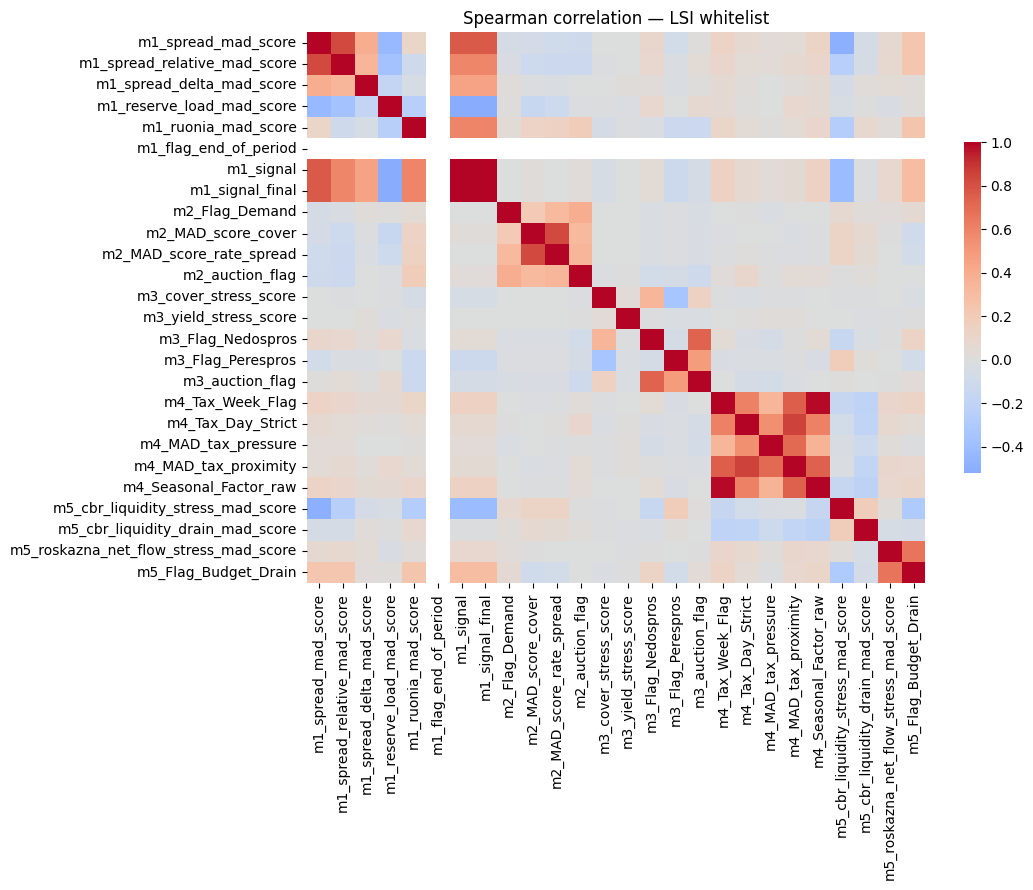

In [7]:
fig, ax, corr = u.correlation_heatmap(d, av, method='spearman'); plt.show()

### Сильно скоррелированные пары (|rho| > порога)

## Parameters
Меняй значения здесь и перезапускай ноутбук.

In [8]:
CORR_THRESHOLD = 0.9

In [9]:
import itertools
pairs = []
for i,j in itertools.combinations(av,2):
    r = u.spearman(d[i], d[j])
    if abs(r) >= CORR_THRESHOLD:
        pairs.append({'a':i,'b':j,'spearman':round(r,3)})
pd.DataFrame(pairs).sort_values('spearman', key=lambda s: s.abs(), ascending=False)

/Users/nikitabaslykov/Documents/Работа/Казначейство/MathMode_LiquidityCatchers_RuLiquiditySentinel/lab/utils.py:217: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return float(stats.spearmanr(a[m], b[m]).correlation)


,a,b,spearman
0,m1_signal,m1_signal_final,1.000
1,m4_Tax_Week_Flag,m4_Seasonal_Factor_raw,0.987


### Распределения по модулям M1–M5
Меняй модуль в параметре.

## Parameters
Меняй значения здесь и перезапускай ноутбук.

In [10]:
MODULE = 'm1'   # m1 / m2 / m3 / m4 / m5

### Описание первых четырех признаков модуля М1

* **`m1_spread_mad_score` (Абсолютный избыток резервов)**
  * **Как считается:** MAD-score от абсолютного спреда резервов: $Spread = Balances_{actual} - Reserves_{required}$ (в рублях) относительно скользящей медианы за 3 года.
  * **Что означает:** Объём «лишних» рублей, накопленных банками на корсчетах сверх требований ЦБ. Рост показателя в плюс означает защитное накопление («хординг») ликвидности из-за рисков (сигнал стресса).

* **`m1_spread_relative_mad_score` (Относительный избыток резервов)**
  * **Как считается:** MAD-score от относительного спреда резервов: $Spread_{relative} = \frac{Spread}{Reserves_{required}} \times 100\%$.
  * **Что означает:** Процент перевыполнения норматива ЦБ. Очищает показатель от роста масштаба банковского сектора во времени, делая сопоставимыми периоды разных лет (например, 2014 и 2024 гг.).

* **`m1_spread_delta_mad_score` (Скорость изменения резервов)**
  * **Как считается:** MAD-score от изменения спреда между смежными периодами усреднения: $\Delta Spread = Spread_t - Spread_{t-1}$.
  * **Что означает:** Скорость стягивания ликвидности банками. Резкие скачки вверх сигнализируют о внезапном переходе рынка в «режим паники».

* **`m1_reserve_load_mad_score` (Коэффициент резервной нагрузки)**
  * **Как считается:** MAD-score от соотношения: $Load = \frac{Reserves_{required} + Reserves_{accounting}}{Balances_{actual}} \times 100\%$.
  * **Что означает:** Доля «замороженных» под обязательства ЦБ денег в общих остатках на корсчетах. Высокие уровни указывают на дефицит свободных средств для проведения клиентских платежей и общую уязвимость к шокам ликвидности.


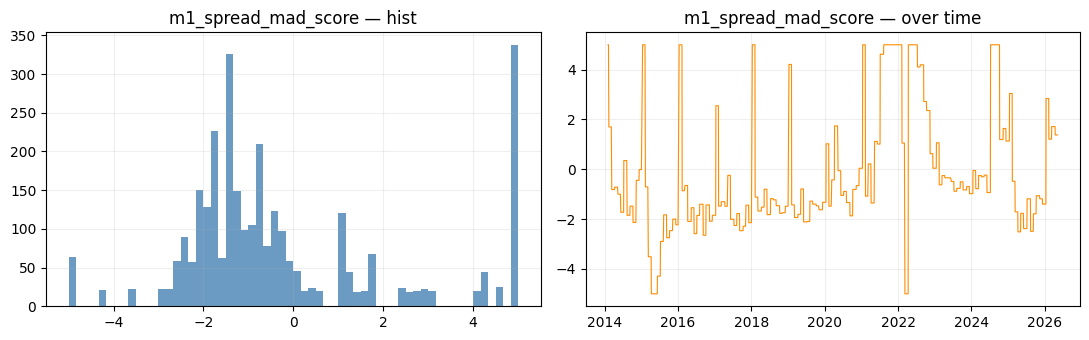

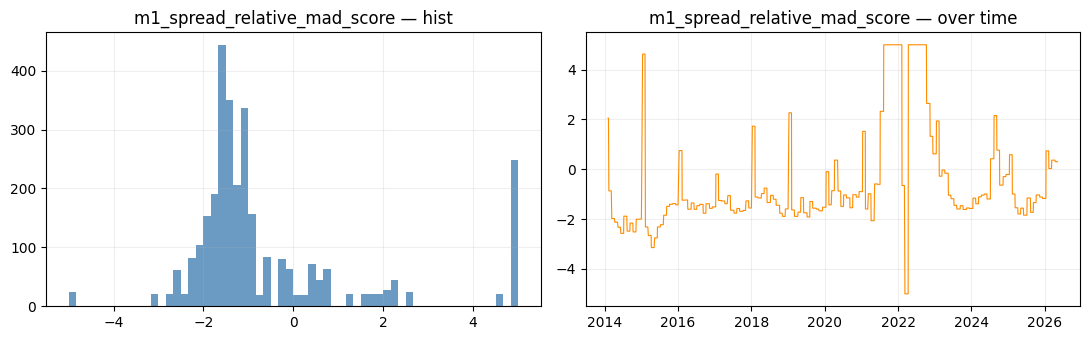

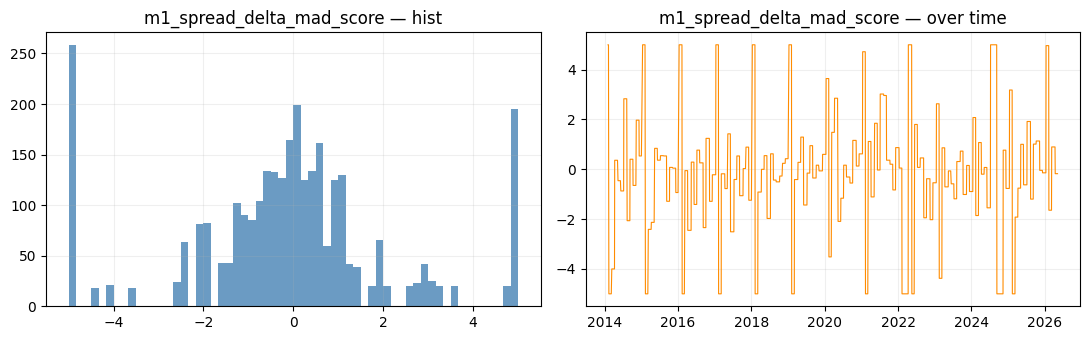

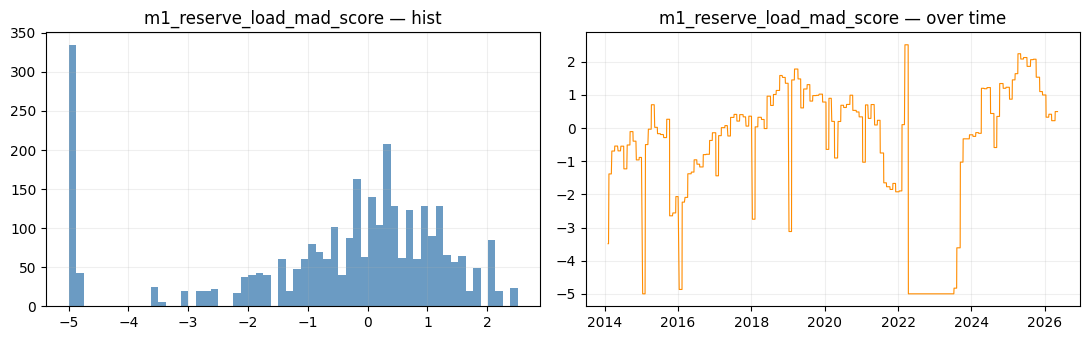

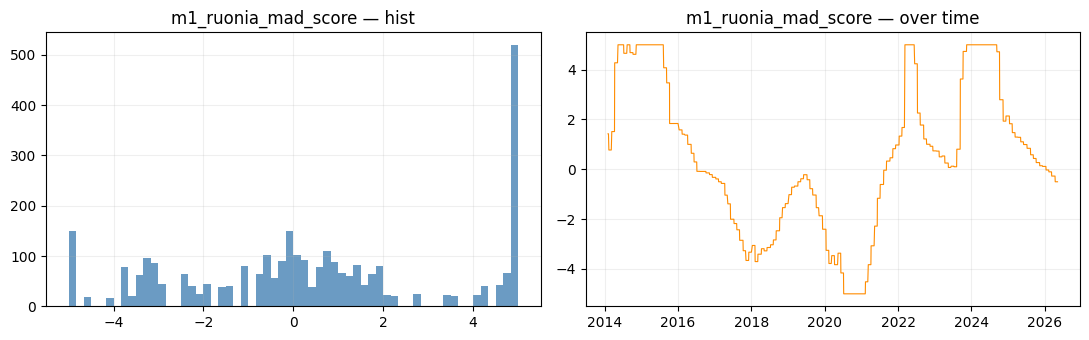

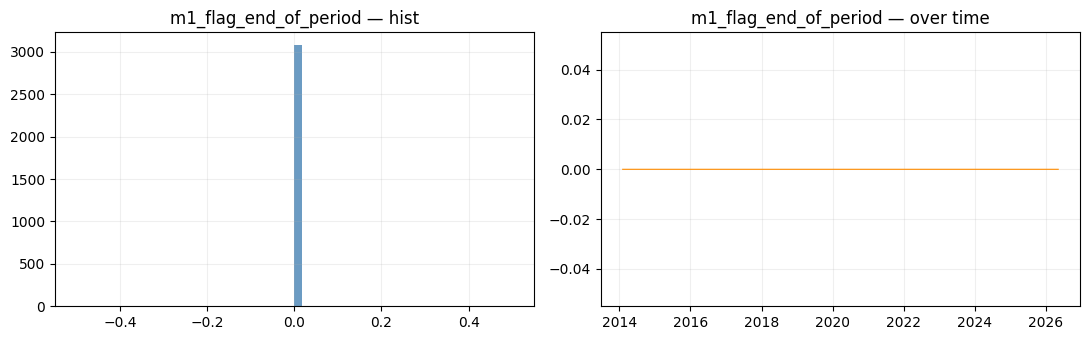

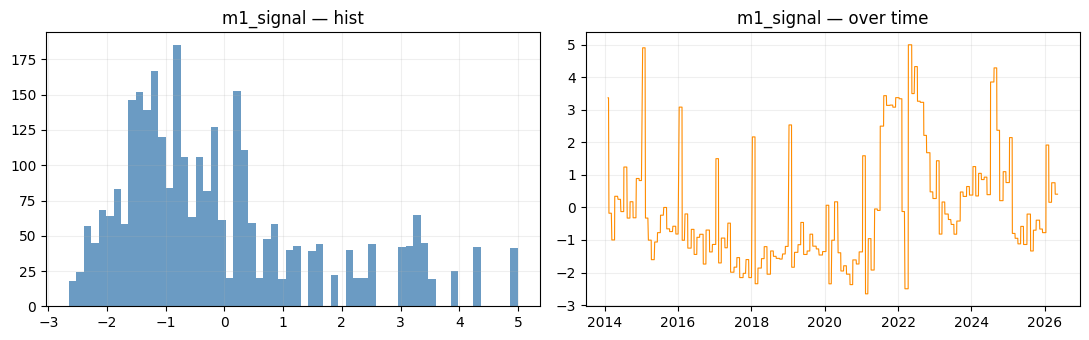

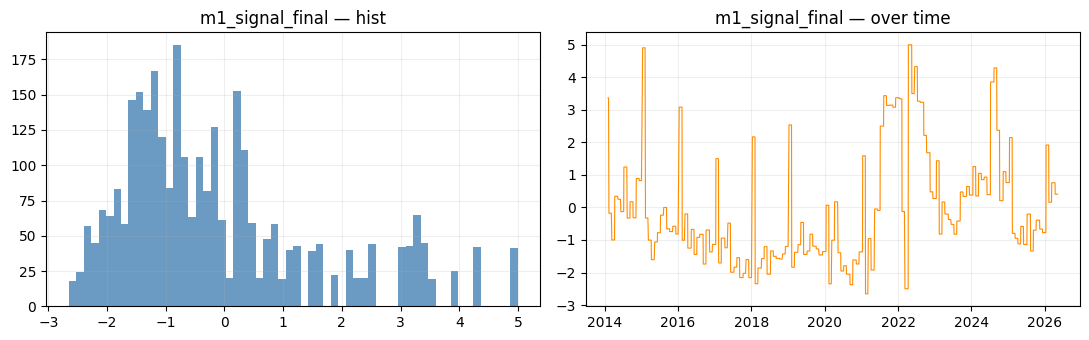

In [13]:
mod_feats = u.split_features_by_module(av).get(MODULE, [])
for f in mod_feats:
    fig, axes = u.plot_feature_distribution(d, f); plt.show()

### M4 Tax_Week_Flag частота и M5 Roskazna до/после 2021

In [12]:
print('Tax_Week_Flag share==1:', round(float((pd.to_numeric(d['m4_Tax_Week_Flag'],errors='coerce')==1).mean()),3))
rk = 'm5_roskazna_net_flow_stress_mad_score'
if rk in d.columns:
    pre = d[d['date'] < '2021-01-01'][rk]
    post = d[d['date'] >= '2021-01-01'][rk]
    print(f'{rk}: pre-2021 nonzero share', round(float((pre.fillna(0)!=0).mean()),3),
          '| post-2021', round(float((post.fillna(0)!=0).mean()),3))

Tax_Week_Flag share==1: 0.72
m5_roskazna_net_flow_stress_mad_score: pre-2021 nonzero share 0.0 | post-2021 0.974


---
# Поблочный разбор распределений (M2–M5)

Ниже — детальные секции по каждому модулю в стиле блока M1: краткое описание, сводная таблица с перцентилями, графики и мини-блок *Observations to check manually*. Параметры рисования — в ячейке ниже.

## Parameters (deep-dive)
Меняй и перезапускай секции ниже.

In [ ]:
BINS = 40
NCOLS = 3
LOCAL_WINDOW_DAYS = 365
EPISODES = u.STRESS_EPISODES
mods = u.split_features_by_module(av)
d_local = d[d['date'] >= d['date'].max() - pd.Timedelta(days=LOCAL_WINDOW_DAYS)]
print('rows total:', len(d), '| local window rows:', len(d_local))
{k: mods.get(k, []) for k in ['m2','m3','m4','m5']}

## M2 — REPO Auctions Feature Distributions

**Что это за модуль.** M2 описывает аукционы РЕПО Банка России — это **sparse, event-driven** модуль. Ненулевые значения появляются в основном **в дни аукционов**; в остальные дни признаки зануляются.

**Важно не перепутать.** Ноль здесь означает **отсутствие события** (аукциона), а не нулевой рыночный стресс. Поэтому распределения «по всем дням» смещены к нулю, и смотреть стоит **отдельно по дням аукционов**.

**Какие признаки смотрим:** `m2_auction_flag` (маркер события), `m2_Flag_Demand` (повышенный спрос), `m2_MAD_score_cover` (bid-to-cover), `m2_MAD_score_rate_spread` (премия ставки).

In [ ]:
u.summarize_features_extended(d, mods['m2'])

### Распределения M2 (все дни) — small multiples + boxplot

In [ ]:
fig, _ = u.plot_module_small_multiples(d, mods['m2'], bins=BINS, ncols=NCOLS,
    title='M2 — distributions (all days)'); plt.show()
feats = [f for f in mods['m2'] if f in d.columns]
fig, ax = plt.subplots(figsize=(8,3.5))
ax.boxplot([pd.to_numeric(d[f], errors='coerce').dropna() for f in feats], labels=feats, vert=True)
ax.set_title('M2 — boxplot (all days)'); ax.tick_params(axis='x', rotation=30); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Распределения M2 только в дни аукционов (`m2_auction_flag == 1`)

In [ ]:
m2_mask = pd.to_numeric(d['m2_auction_flag'], errors='coerce') == 1
print('auction days:', int(m2_mask.sum()), '| share of all days:', round(float(m2_mask.mean()), 4))
score_feats = ['m2_MAD_score_cover', 'm2_MAD_score_rate_spread', 'm2_Flag_Demand']
u.plot_module_small_multiples(d, score_feats, mask=m2_mask, bins=BINS, ncols=NCOLS,
    title='M2 — distributions on AUCTION days only')
plt.show()

### Timeline ненулевых сигналов M2

In [ ]:
u.plot_nonzero_timeline(d, mods['m2'], episodes=EPISODES, title='M2 non-zero signals')
plt.show()

#### Observations to check manually (M2)
- Are non-zero M2 days visually concentrated around stress periods (подсвеченные окна)?
- На дни аукционов `m2_MAD_score_cover` имеет осмысленный разброс или почти всегда 0?
- Достаточно ли ненулевых наблюдений, чтобы M2 вообще влиял в PCA?
- `m2_Flag_Demand` — не слишком ли он редкий, чтобы быть информативным?

## M3 — OFZ Auctions Feature Distributions

**Что это за модуль.** M3 описывает аукционы ОФЗ Минфина — тоже **sparse, event-driven**.

**Важно не перепутать.** `m3_cover_stress_score` — это **инверсия** cover MAD (= `-m3_MAD_score_cover`): низкий спрос на размещении = стресс, поэтому знак перевёрнут. Смотреть отдельно **дни аукционов** и **не-аукционные дни**. `m3_Flag_Perespros` (переспрос) может быть **почти мёртвым** в коротком local-окне.

**Какие признаки смотрим:** `m3_auction_flag`, `m3_cover_stress_score`, `m3_yield_stress_score`, `m3_Flag_Nedospros`, `m3_Flag_Perespros`.

In [ ]:
u.summarize_features_extended(d, mods['m3'])

### Распределения M3 (все дни) — small multiples + boxplot

In [ ]:
fig, _ = u.plot_module_small_multiples(d, mods['m3'], bins=BINS, ncols=NCOLS,
    title='M3 — distributions (all days)'); plt.show()
feats = [f for f in mods['m3'] if f in d.columns]
fig, ax = plt.subplots(figsize=(9,3.5))
ax.boxplot([pd.to_numeric(d[f], errors='coerce').dropna() for f in feats], labels=feats, vert=True)
ax.set_title('M3 — boxplot (all days)'); ax.tick_params(axis='x', rotation=30); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Распределения M3 только в дни аукционов (`m3_auction_flag == 1`)

In [ ]:
m3_mask = pd.to_numeric(d['m3_auction_flag'], errors='coerce') == 1
print('auction days:', int(m3_mask.sum()), '| share:', round(float(m3_mask.mean()), 4))
u.plot_module_small_multiples(d, ['m3_cover_stress_score','m3_yield_stress_score'],
    mask=m3_mask, bins=BINS, ncols=2, title='M3 — stress scores on AUCTION days only')
plt.show()

### Timeline аукционов / стресс-сигналов M3

In [ ]:
u.plot_nonzero_timeline(d, mods['m3'], episodes=EPISODES, title='M3 non-zero signals')
plt.show()

### Отдельная проверка флагов `m3_Flag_Nedospros` / `m3_Flag_Perespros`

In [ ]:
for f in ['m3_Flag_Nedospros','m3_Flag_Perespros']:
    s = pd.to_numeric(d[f], errors='coerce')
    print(f'{f}: ones={int((s==1).sum())} | share={round(float((s==1).mean()),4)}')

### Zero-rate M3 в последнем 365-дневном окне (local window)

In [ ]:
zr_full = u.compute_zero_null_stats(d, mods['m3']).set_index('feature')['zero_rate']
zr_loc = u.compute_zero_null_stats(d_local, mods['m3']).set_index('feature')['zero_rate']
pd.DataFrame({'zero_rate_full': zr_full, 'zero_rate_local_365d': zr_loc}).round(4)

#### Observations to check manually (M3)
- Does M3 signal contain enough non-zero observations to matter in PCA?
- `m3_cover_stress_score` действительно ведёт себя как инверсия cover (высокое = слабый спрос)?
- `m3_Flag_Perespros` в local-окне почти полностью нулевой? Тогда он там бесполезен.
- Совпадают ли по датам аукционы M3 и M2 (общие event-дни)?

## M4 — Tax Calendar Feature Distributions

**Что это за модуль.** M4 — **детерминированный календарный** модуль налоговых выплат. Это **не** рыночный объём изъятия ликвидности, а **календарный контекст** (когда «должно» быть напряжение из-за налогов).

**Важно не перепутать.** `Tax_Week_Flag` может быть **очень частым** (длинные налоговые окна), поэтому он плохо ведёт себя как редкое стресс-событие. `MAD_tax_pressure` (интенсивность налоговых событий) и `MAD_tax_proximity` (близость к дню платежа) имеют **разный смысл**. M4 важен для интерпретации, но из-за регулярности может давать **высокий структурный вклад в PCA**.

**Какие признаки смотрим:** `m4_Tax_Week_Flag`, `m4_Tax_Day_Strict`, `m4_MAD_tax_pressure`, `m4_MAD_tax_proximity`, `m4_Seasonal_Factor_raw`.

In [ ]:
u.summarize_features_extended(d, mods['m4'])

### Частоты бинарных флагов M4

In [ ]:
rows = []
for f in ['m4_Tax_Week_Flag','m4_Tax_Day_Strict']:
    s = pd.to_numeric(d[f], errors='coerce')
    rows.append({'flag': f, 'ones': int((s==1).sum()), 'share_ones': round(float((s==1).mean()),4)})
pd.DataFrame(rows)

### Распределения continuous-фич M4 — small multiples + boxplot

In [ ]:
cont = ['m4_MAD_tax_pressure','m4_MAD_tax_proximity','m4_Seasonal_Factor_raw']
u.plot_module_small_multiples(d, cont, bins=BINS, ncols=NCOLS, title='M4 — continuous features'); plt.show()
fig, ax = plt.subplots(figsize=(8,3.5))
ax.boxplot([pd.to_numeric(d[f], errors='coerce').dropna() for f in cont], labels=cont, vert=True)
ax.set_title('M4 — boxplot (continuous)'); ax.tick_params(axis='x', rotation=20); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Timeline налоговых флагов

In [ ]:
u.plot_nonzero_timeline(d, ['m4_Tax_Week_Flag','m4_Tax_Day_Strict'], episodes=EPISODES,
    title='M4 tax flags timeline')
plt.show()

### M4 до и после налоговой реформы ЕНП (2023, `Regime_Post_ENP`)

In [ ]:
split_col = 'm4_Regime_Post_ENP' if 'm4_Regime_Post_ENP' in d.columns else None
if split_col is not None:
    grp = pd.to_numeric(d[split_col], errors='coerce') == 1
else:
    grp = d['date'] >= '2023-01-01'
cmp = []
for f in ['m4_MAD_tax_pressure','m4_MAD_tax_proximity','m4_Tax_Week_Flag']:
    s = pd.to_numeric(d[f], errors='coerce')
    cmp.append({'feature': f,
                'mean_pre2023': round(float(s[~grp].mean()),4),
                'mean_post2023': round(float(s[grp].mean()),4),
                'share_nonzero_pre': round(float((s[~grp].fillna(0)!=0).mean()),4),
                'share_nonzero_post': round(float((s[grp].fillna(0)!=0).mean()),4)})
pd.DataFrame(cmp)

### Почему M4 может часто попадать в attribution
M4-фичи регулярны и имеют заметный std при низкой доле нулей → после StandardScaler они дают стабильный вклад в компоненты. Сравним долю нулей и std M4 со средним по остальным модулям.

In [ ]:
ext_all = u.summarize_features_extended(d, av)
by_mod = ext_all.groupby('module').agg(mean_zero_rate=('zero_rate','mean'),
    mean_std=('std','mean'), n=('feature','size')).round(3)
by_mod

#### Observations to check manually (M4)
- Is M4 too frequent to behave like a stress event (особенно `Tax_Week_Flag`)?
- `MAD_tax_pressure` и `MAD_tax_proximity` — видно ли, что у них разный смысл/форма?
- Изменилось ли поведение M4 после ЕНП-2023?
- Низкий ли у M4 zero-rate относительно M2/M3 (т.е. он «всегда включён»)?

## M5 — CBR Liquidity and Treasury Feature Distributions

**Что это за модуль.** M5 — **центральный структурный** модуль ликвидности: дневной стресс ликвидности банковского сектора (ЦБ) и чистые потоки Казначейства (Roskazna).

**Важно не перепутать.** Часть Roskazna-сигналов появляется **только после 2021 г.** (до этого ряд преимущественно пустой/нулевой). CBR liquidity stress смотреть **отдельно** от Roskazna net flow stress. `m5_Flag_Budget_Drain` — **бинарный и sparse**. M5 важен для **Global**, но его роль в **Local directional signal неоднозначна**.

**Какие признаки смотрим:** `m5_cbr_liquidity_stress_mad_score`, `m5_cbr_liquidity_drain_mad_score`, `m5_roskazna_net_flow_stress_mad_score`, `m5_Flag_Budget_Drain`.

In [ ]:
u.summarize_features_extended(d, mods['m5'])

### Распределения continuous M5 stress-фич — small multiples + boxplot

In [ ]:
cont = ['m5_cbr_liquidity_stress_mad_score','m5_cbr_liquidity_drain_mad_score',
        'm5_roskazna_net_flow_stress_mad_score']
u.plot_module_small_multiples(d, cont, bins=BINS, ncols=NCOLS, title='M5 — CBR/Roskazna stress'); plt.show()
fig, ax = plt.subplots(figsize=(9,3.5))
ax.boxplot([pd.to_numeric(d[f], errors='coerce').dropna() for f in cont], labels=cont, vert=True)
ax.set_title('M5 — boxplot (stress scores)'); ax.tick_params(axis='x', rotation=15); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

### Частота `m5_Flag_Budget_Drain`

In [ ]:
s = pd.to_numeric(d['m5_Flag_Budget_Drain'], errors='coerce')
pd.DataFrame([{'flag':'m5_Flag_Budget_Drain','ones':int((s==1).sum()),
               'share_ones':round(float((s==1).mean()),4)}])

### Timeline M5 stress-сигналов

In [ ]:
u.plot_nonzero_timeline(d, mods['m5'], episodes=EPISODES, title='M5 non-zero signals')
plt.show()

### Roskazna: pre-2021 vs post-2021 (доступность и распределение)

In [ ]:
rk = 'm5_roskazna_net_flow_stress_mad_score'
pre = d[d['date'] < '2021-01-01']
post = d[d['date'] >= '2021-01-01']
tbl = pd.DataFrame([
  {'period':'pre-2021','rows':len(pre),
   'null_rate':round(float(pd.to_numeric(pre[rk],errors='coerce').isna().mean()),4),
   'zero_rate':round(float((pd.to_numeric(pre[rk],errors='coerce')==0).mean()),4),
   'std':round(float(pd.to_numeric(pre[rk],errors='coerce').std()),4)},
  {'period':'post-2021','rows':len(post),
   'null_rate':round(float(pd.to_numeric(post[rk],errors='coerce').isna().mean()),4),
   'zero_rate':round(float((pd.to_numeric(post[rk],errors='coerce')==0).mean()),4),
   'std':round(float(pd.to_numeric(post[rk],errors='coerce').std()),4)}])
tbl

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
axes[0].hist(pd.to_numeric(pre[rk],errors='coerce').dropna(), bins=BINS, color='gray', alpha=0.8)
axes[0].set_title(f'{rk}\npre-2021')
axes[1].hist(pd.to_numeric(post[rk],errors='coerce').dropna(), bins=BINS, color='seagreen', alpha=0.8)
axes[1].set_title(f'{rk}\npost-2021')
for axx in axes: axx.grid(alpha=0.2)
plt.tight_layout(); plt.show()

#### Observations to check manually (M5)
- Does Roskazna only become active after 2021 (pre-2021 zero/null rate near 1)?
- Which M5 feature has the strongest structural variation (наибольший std)?
- CBR liquidity stress и drain — насколько они скоррелированы между собой?
- `m5_Flag_Budget_Drain` достаточно частый, чтобы быть полезным, или почти мёртвый?

## Cross-Module Summary

**Зачем сравнивать модули.** Признаки внутри whitelist имеют **разную природу**, и это важно при интерпретации PCA/IsolationForest: модель смешивает их в одном пространстве, хотя «ноль» в каждом модуле значит разное.

- **M1** — carry-forward / period-level (меняется на границах периодов усреднения).
- **M2 / M3** — sparse event-driven (ненулевые только в дни аукционов).
- **M4** — deterministic calendar (регулярный, почти всегда включён).
- **M5** — daily structural liquidity + post-2021 Roskazna.

Ниже — единая таблица и сравнительные графики, чтобы увидеть аномалии типов сразу.

### Единая таблица: stats + feature_type guess

In [ ]:
ext = u.summarize_features_extended(d, av)[['module','feature','null_rate','zero_rate','n_unique','std']]
types = u.classify_feature_type(d, av)[['feature','feature_type']]
cross = ext.merge(types, on='feature').sort_values(['module','feature']).reset_index(drop=True)
cross

### Zero-rate по фичам (цвет = модуль)

In [ ]:
u.bar_metric_by_module(cross, 'zero_rate', title='Zero-rate by feature (color = module)')
plt.show()

### Std по фичам (цвет = модуль)

In [ ]:
u.bar_metric_by_module(cross, 'std', title='Std by feature (color = module)')
plt.show()

### Список подозрительных фич

In [ ]:
import itertools
suspicious = {}
suspicious['constant_or_dead'] = cross.loc[cross['feature_type']=='dead_or_constant','feature'].tolist()
suspicious['very_sparse(zero>=0.95)'] = cross.loc[cross['zero_rate']>=0.95,'feature'].tolist()
hf = cross[(cross['feature_type']=='binary') & (cross['zero_rate']<=0.5)]
suspicious['high_freq_binary_flags'] = hf['feature'].tolist()
# near-duplicate пары (|spearman| > 0.95) внутри whitelist
dups = []
for a, b in itertools.combinations(av, 2):
    r = u.spearman(d[a], d[b])
    if abs(r) > 0.95:
        dups.append((a, b, round(r, 3)))
suspicious['near_duplicate_pairs'] = dups
for k, v in suspicious.items():
    print(k, '->', v)

### What to inspect next
- Стоит ли убрать из whitelist constant/dead и одну из near-duplicate пар (см. список выше)?
- Для sparse event-модулей (M2/M3): корректно ли zero-fill смешивается с continuous MAD-scores в одном PCA-пространстве, или их вклад «съедается» нулями?
- Не доминирует ли M4 в structural attribution просто из-за регулярности (низкий zero-rate, стабильный std)? Перепроверить в `05_explainability_lab`.
- Какие фичи имеют тяжёлые хвосты (p99 ≫ p95) и как это влияет на StandardScaler — кандидаты на winsorize/clip.
- Pre/post-2021 разрыв Roskazna: не вносит ли он искусственный режимный сдвиг в Global-шкалу?

## Notes / Open questions

- Подтверди: m1_signal_final == m1_signal (дубль) и flag_end_of_period вклад.
- Какие ещё пары почти дублируют друг друга — кандидаты на чистку whitelist.
- M2/M3 sparsity — учитывать при интерпретации вкладов модулей.